U prethodnom delu smo obavili Exploratory Data Analysis koji nam je ukazao na odsustvo linearne autokorelacije u okviru logaritamskih prinosa kriptovaluta. U ovom dokumentu ćemo iskoristiti nekoliko algoritama kako bismo dobili stope uspešnosti koje naša metoda predvidjanja mora nadmašiti kako bi predstavljala validan prediktor za kretanje kriptovaluta. Algoritmi u pitanju su:
- Majority Rule: posmatranje koje kretanje se najviše pojavljivalo u trening setu: ako se u toku treninga Bitcoin uglavnom kretao na gore, onda za ceo test predvidjamo da će ići na gore i obratno. Ovaj algoritam je izuzetno naivan i ne gleda nikakve zavisnosti izmedju ranijih i sadašnjih vrednosti. Bitno je naglasiti da on ipak uči nešto iz podataka: uči koja klasa dominira u trening prozoru.
- Always Predict Up: konstantno predvidjanje rasta, bez obzira na trening podatke. Ovaj model ne uči ništa, pa nam služi kao apsolutni pod: ako neki model ne uspe da nadmaši ni konstantno predvidjanje, onda ono što je naučio iz podataka nije vredelo. Uključujemo ga zato što Majority Rule, iako naivan, može da bude gori od konstante ukoliko se učestalost klasa menja izmedju trening i test perioda.
- Logistička regresija: kao parametre koristimo istorijske podatke do 5 dana unazad. Razlog zašto koristimo LR ovde je jer, iako ne postoji direktna autokorelacija izmedju prinosa, moramo testirati pretpostavku da neka linearna kombinacija istorijskih podataka može ipak doprineti predvidjanju kretanja budućih vrednosti.
- Gradient Boosted Trees: takodje koristimo istorijske podatke kao parametre. Glavni razlog za korišćenje ovog algoritma jeste korišćenje nelinearnih veza izmedju istorijskih i sadašnjih podataka u svrhu predikcije.

Takodje je bitno naglasiti da koristimo walk-forward metodu umesto k-fold, jer k-fold omogućava da u trening set zadju podaci koji su iz budućnosti, kao i da u test set dodju podaci koji su se desili ranije u odnosu na pojedine obzervacije iz trening seta.
S obzirom na Ljung-Box test koji smo odradili u prošlom delu, očekujemo da će algoritmi imati stopu uspešnosti ~50%, što bi ukazalo na neadekvatnost ulaznih podataka, a ne na loše odabrane modele. U slučaju da u ovom delu nekako dobijemo uspešnost koja je značajno iznad 50%, to nam potencijalno ukazuje na curenje podataka više nego na stvarno pronađen signal.

Za kraj, samo povećanje stope uspešnosti u odnosu na najbolji naivni model ne mora da bude statistički značajno; razlika od jednog procentnog poena na ovom broju predikcija je u rangu statističkog šuma. Zbog toga ćemo na kraju ovog dela da uvedemo bootstrap intervale poverenja, koji će nam ukazati koliko povećanje uspešnosti je zapravo dokaz stvarnog poboljšanja.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from loader import load_dataset
from features import build_features

In [13]:
df = load_dataset("1d")

print(len(df))
print(df['date'].iloc[0], '->', df['date'].iloc[-1])

df, FEATURES = build_features(df)

1662
2022-01-01 00:00:00 -> 2026-07-20 00:00:00


In [14]:
def walk_forward(df, model, feature_cols, initial_train=500, step=50):
    X = df[feature_cols].values
    y = df['label'].values
    n = len(df)

    all_preds = []
    all_truth = []

    boundary = initial_train
    while boundary < n:
        test_end = min(boundary + step, n)

        X_train, y_train = X[:boundary], y[:boundary]
        X_test,  y_test  = X[boundary:test_end], y[boundary:test_end]
        n_test = test_end - boundary

        if model == 'majority':
            # Predvidjanje test vrednosti na osnovu vrednosti koja se najviše pojavljivala u okviru trening vrednosti
            if sum(y_train) > boundary / 2:
                preds = n_test * [1]
            else:
                preds = n_test * [0]
        elif model == 'always_predict_up':
            preds = n_test * [1]
            # Uvek predvidjamo da će kretanje cene ići na gore.
        else:
            #Sprečavamo curenje podataka tako što radimo fitting samo na podacima za trening, dok test podatke samo transformišemo
            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train)
            X_test_s = scaler.transform(X_test)
            model.fit(X_train_s, y_train)
            preds = model.predict(X_test_s)

        all_preds.extend(preds)
        all_truth.extend(y_test)

        boundary = test_end

    return np.array(all_preds), np.array(all_truth)

In [15]:
models = {
    'majority':  'majority',
    'logistic':  LogisticRegression(max_iter=1000),
    'gbt':       GradientBoostingClassifier(random_state=42),
    'always_predict_up': 'always_predict_up'
}

print(f"\n{'model':<20}{'n_preds':<10}{'accuracy':<10}")

majority_correct = []
logistic_correct = []
gbt_correct = []
always_up_correct = []

for name, mdl in models.items():
    preds, truth = walk_forward(df, mdl, FEATURES)
    if name == 'majority':
        majority_correct = (preds == truth)
    elif name == 'logistic':
        logistic_correct = (preds == truth)
    elif name == 'always_predict_up':
        always_up_correct = (preds == truth)
    elif name == 'gbt':
        gbt_correct = (preds == truth)
    acc = (preds == truth).mean()
    print(f"{name:<20}{len(preds):<10}{acc:.4f}")


model               n_preds   accuracy  
majority            1156      0.4853
logistic            1156      0.5009
gbt                 1156      0.5087
always_predict_up   1156      0.5061


## Intervali poverenja preko bootstrap-a

Do sada smo dobili četiri broja: tačnost za majority rule, always predict up, logističku regresiju i GBT. Sve četiri se vrte oko 0,50. Ali sam broj tačnosti nam ne govori mnogo. Ako GBT ima 0,5004 a konstantno predvidjanje rasta 0,5056, da li to znači da je konstanta bolja, ili je ta razlika samo šum? Ne možemo da odgovorimo na to dok ne znamo koliko taj broj varira.

Tu ulazi interval poverenja. Umesto da gledamo tačnost bez dalje provere, definisaćemo raspon u kome se prava vrednost verovatno nalazi. Odmah da naglasimo šta nam je zapravo cilj: ne zanima nas toliko interval oko tačnosti pojedinačnog modela, koliko interval oko razlike u tačnosti izmedju dva modela. Pitanje na koje odgovaramo nije "kolika je tačnost GBT-a", nego "da li je razlika izmedju GBT-a i konstantnog predvidjanja veća od šuma".

Bitno je razumeti šta 95% interval poverenja zapravo znači: ne znači da postoji 95% šanse da je prava vrednost unutar tog raspona. Prava vrednost je fiksan broj, ili jeste ili nije unutar intervala. Ono što 95% znači jeste da metod kojim pravimo interval, ako bismo ga ponovili na mnogo različitih uzoraka, daje interval koji pokriva pravu vrednost u 95% slučajeva. To znači da se nasumičnost nalazi u proceduri, ne u samoj vrednosti koju procenjujemo.

Ideja je: nemamo pristup pravoj raspodeli iz koje su podaci nastali, ali imamo empirijsku raspodelu, odnosno same podatke. Empirijska raspodela je nepristrasna procena prave raspodele, i to bez ikakvih pretpostavki o obliku. Zato vučemo uzorke sa ponavljanjem iz naših podataka (što je isto što i povlačenje uzoraka iz empirijske raspodele), računamo tačnost na svakom takvom uzorku, i gledamo koliko ti brojevi variraju. To variranje je procena onoga što bismo videli da smo skupljali nove uzorke iz stvarnog sveta. Ovo je takozvana bootstrap metoda.

Za sam interval ne pretpostavljamo normalnost. Koristimo interval na osnovu percentila: sortiramo bootstrap tačnosti, odsečemo najmanjih 2,5% i najvećih 2,5%, i ono što ostane u sredini je naš interval. Kroz ovu metodu uklanjamo potrebe za simetričnošću raspodele.

### Uparivanje modela

Još jedna stvar koju moramo naglasiti: nas ne zanima samo interval oko tačnosti pojedinačnog modela, već interval oko razlike izmedju dva modela. Zbog toga u svakoj bootstrap replikaciji izvlačimo jedan skup indeksa i primenjujemo ga na oba niza pogodaka istovremeno. Oba modela se, dakle, ocenjuju nad potpuno istim danima u svakoj replikaciji.

Ovo je bitno jer bez uparivanja merimo dve stvari odjednom: stvarnu razliku izmedju modela i variranje koje dolazi od toga koji su dani slučajno upali u uzorak. Pošto oba modela gledaju iste dane, drugi izvor variranja se poništava, pa ono što ostaje u intervalu jeste neslaganje izmedju modela, a ne slučajnost izbora dana.

### Standardni vs blok bootstrap

Ovde postoji zamka. Obično bootstrap izvlači uzorke pojedinačne tačke sa ponavljanjem, potpuno nezavisno. To je legitimno samo ako su tačke nezavisne jedna od druge. Naš niz pogodaka (1 ako je model pogodio smer tog dana, 0 ako nije) je vremenski niz. Ako u tom nizu postoji zavisnost, na primer ako pogodak danas znači da ćemo verovatno pogoditi i sutra, onda nezavisno uzorkovanje razbija tu strukturu. Rezultat je bootstrap raspodela koja je preuska, samim tim i interval koji je preuzak, pa prijavljujemo lažnu preciznost. Ovo je tačno onaj scenario koji bi nam dozvolio da greškom kažemo da je jedan model bolji od drugog.

Rešenje za to je blok bootstrap: umesto pojedinačnih tačaka, uzorkujemo susedne blokove uzastopnih tačaka. Unutar bloka redosled ostaje netaknut, pa se lokalna zavisnost čuva. Jedino se lomi zavisnost na spojevima gde se blokovi lepe, ali ako je dužina bloka dovoljno velika, tačke udaljenije od te dužine su skoro nezavisne.

Odluka između standardnog i blok bootstrap-a se svodi na jedno pitanje: da li niz pogodaka ima zavisnost koju vredi čuvati. To ne možemo da rešimo razmišljanjem, moramo da proverimo. Zbog toga pre računanja intervala radimo Ljung-Box test na nizu pogodaka svakog modela, da vidimo ima li linearne autokorelacije, i gledamo ACF da vidimo koliko je ta zavisnost velika ako je uopšte ima. Ljung-Box nam kaže da li je zavisnost značajna, a ACF nam kaže kolika je zapravo, jer test može da označi i nebitno malu zavisnost kao značajnu na dovoljno velikom uzorku. Tek na osnovu toga biramo koji bootstrap koristimo.

      lb_stat  lb_pvalue
1    1.000913   0.317090
2    2.187662   0.334931
3    4.535889   0.209111
4    4.604666   0.330317
5    6.283828   0.279573
6    6.325221   0.387762
7    9.451404   0.221850
8   10.396920   0.238265
9   10.569646   0.306364
10  10.612657   0.388480
11  10.616196   0.475954
12  11.356350   0.498651
13  12.254711   0.506876
14  12.276572   0.584102
15  12.308096   0.655575
16  13.791016   0.614279
17  14.215714   0.651778
18  14.288768   0.710082
19  14.577941   0.749019
20  14.647904   0.796188


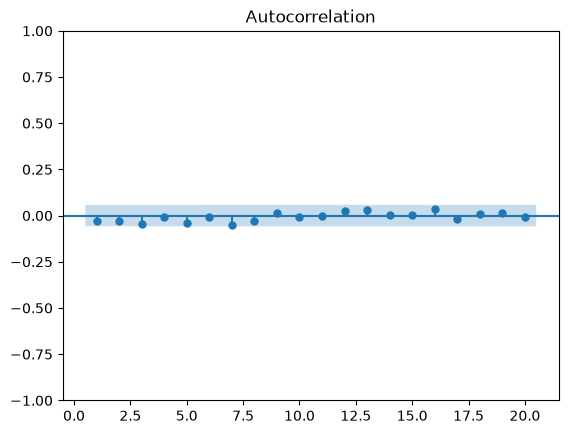

<Figure size 1000x800 with 0 Axes>

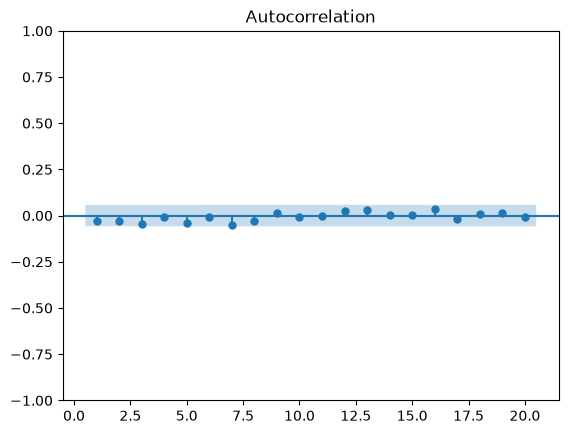

In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

print(acorr_ljungbox(majority_correct, lags=[i for i in range(1, 21)]))
plt.figure(figsize=(10, 8))
plot_acf(majority_correct, lags=[i for i in range(1, 21)])

      lb_stat  lb_pvalue
1    0.632427   0.426467
2    0.663713   0.717590
3    0.685463   0.876618
4    2.526012   0.639984
5    2.722105   0.742735
6    2.892583   0.822203
7    7.539905   0.374905
8    7.627285   0.470698
9   11.092859   0.269398
10  11.096368   0.350060
11  11.412083   0.409413
12  12.098416   0.437808
13  12.562178   0.482170
14  12.846494   0.538645
15  12.854377   0.613545
16  13.079230   0.666956
17  14.417171   0.637383
18  14.473606   0.697737
19  15.115383   0.715236
20  15.288390   0.759675


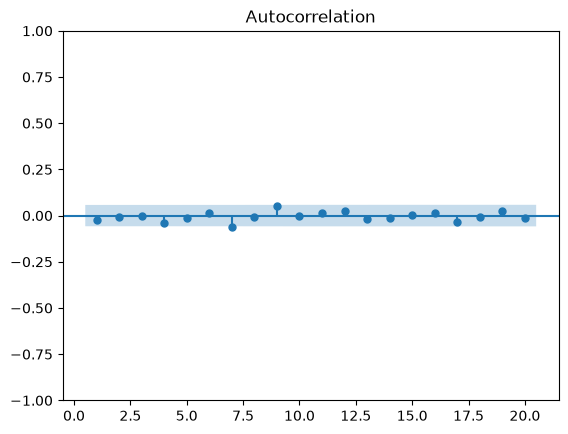

<Figure size 1000x800 with 0 Axes>

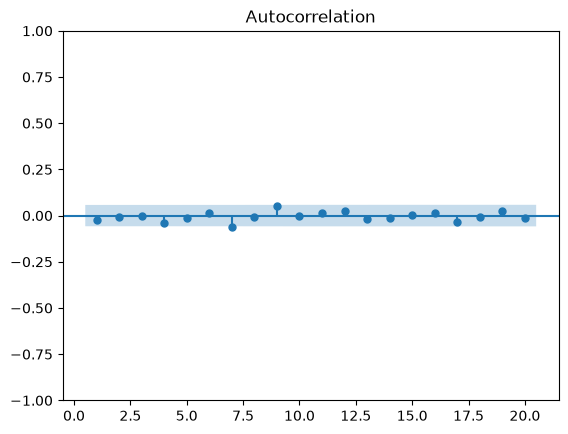

In [17]:
print(acorr_ljungbox(logistic_correct, lags=[i for i in range(1, 21)]))
plt.figure(figsize=(10, 8))
plot_acf(logistic_correct, lags=[i for i in range(1, 21)])

In [18]:
from statsmodels.tsa.stattools import acf

vals, confint = acf(logistic_correct, nlags=20, alpha=0.05)

print(vals)
print(confint)

[ 1.         -0.02335947 -0.00519333 -0.00432827 -0.0397985  -0.01298481
  0.01210177 -0.06315798 -0.00865655  0.05449242 -0.00173313  0.01643301
  0.0242185  -0.01989928 -0.01557401  0.00259213  0.01383784 -0.03374016
 -0.00692647  0.02334744 -0.0121168 ]
[[ 1.          1.        ]
 [-0.08100547  0.03428653]
 [-0.06287077  0.05248412]
 [-0.06200727  0.05335073]
 [-0.09747858  0.01788158]
 [-0.07075607  0.04478645]
 [-0.04567919  0.06988273]
 [-0.12094736 -0.0053686 ]
 [-0.06667485  0.04936175]
 [-0.00353017  0.11251502]
 [-0.05992554  0.05645928]
 [-0.04175957  0.07462559]
 [-0.0339895   0.0824265 ]
 [-0.07814076  0.03834219]
 [-0.07383807  0.04269005]
 [-0.05568576  0.06087003]
 [-0.04444044  0.07211612]
 [-0.09202936  0.02454903]
 [-0.06528053  0.05142759]
 [-0.03500935  0.08170424]
 [-0.07050463  0.04627102]]


      lb_stat  lb_pvalue
1    0.038021   0.845401
2    0.308704   0.856970
3    2.721939   0.436512
4    3.296053   0.509558
5    4.010977   0.547837
6    6.907950   0.329444
7    7.878088   0.343467
8   13.514769   0.095323
9   16.392291   0.059128
10  16.572373   0.084378
11  16.611093   0.119917
12  16.949413   0.151510
13  17.511406   0.176967
14  17.692149   0.221164
15  17.791777   0.273771
16  18.066729   0.320004
17  21.979854   0.185495
18  22.072973   0.228761
19  28.104747   0.081433
20  32.397573   0.039242


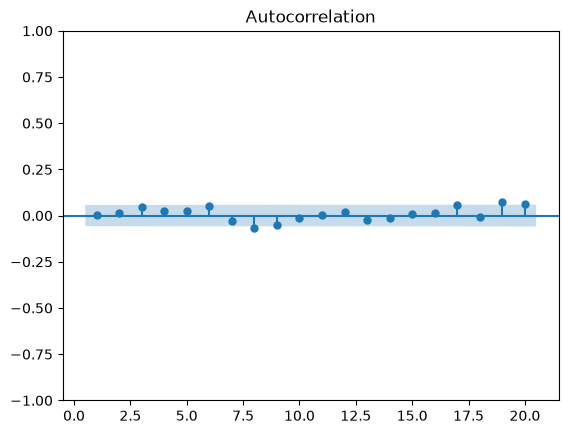

<Figure size 1000x800 with 0 Axes>

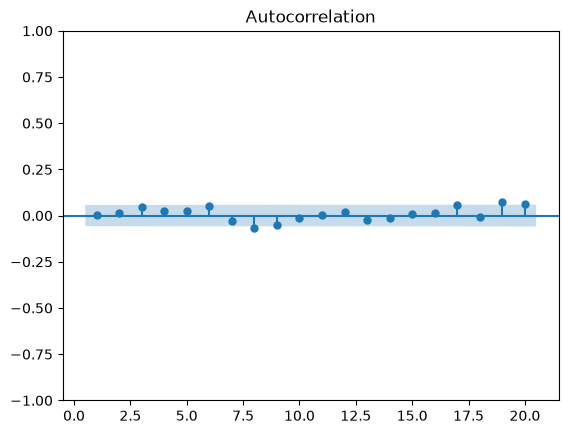

In [19]:
print(acorr_ljungbox(gbt_correct, lags=[i for i in range(1, 21)]))

plt.figure(figsize=(10, 8))
plot_acf(gbt_correct, lags=[i for i in range(1, 21)])

      lb_stat  lb_pvalue
1    0.953114   0.328928
2    1.459345   0.482067
3    4.499503   0.212335
4    4.514280   0.340858
5    6.447349   0.265089
6    6.480005   0.371618
7    9.127459   0.243634
8    9.185041   0.326928
9    9.287948   0.411130
10   9.378401   0.496608
11   9.636432   0.563356
12  10.054715   0.611160
13  11.516083   0.567667
14  11.545890   0.642720
15  11.547096   0.712936
16  14.909774   0.531257
17  14.933087   0.600301
18  14.936187   0.666344
19  15.009550   0.721990
20  17.406042   0.626472


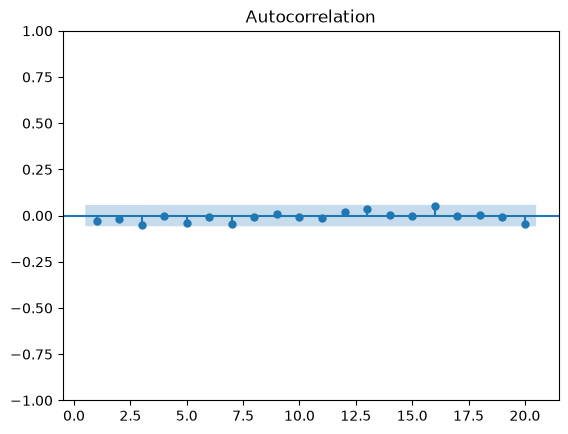

<Figure size 1000x800 with 0 Axes>

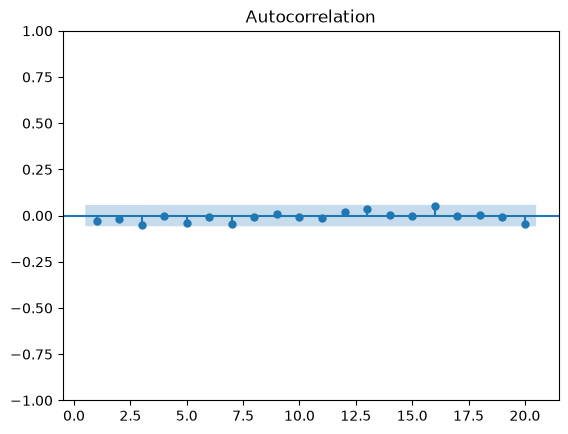

In [20]:
print(acorr_ljungbox(always_up_correct, lags=[i for i in range(1, 21)]))

plt.figure(figsize=(10, 8))
plot_acf(always_up_correct, lags=[i for i in range(1, 21)])

### Šta smo videli

Ljung-Box i ACF smo odradili na nizu pogodaka sva četiri modela.

Majority rule je čist. Sve p vrednosti su daleko iznad 0,05 na svih 20 lag-ova, a ACF ne izlazi iz opsega ni na jednom lag-u. Ovo samo potvrđuje ono što smo videli u EDA, da smer nema linearne zavisnosti.

Logistička regresija je zanimljivija. Ljung-Box počinje da pada ispod 0,05 od lag-a 9 naviše, sa nekoliko p vrednosti u opsegu 0,02 do 0,04. Na prvi pogled deluje kao da ima zavisnosti. Ali kad pogledamo ACF, priča se menja: sve vrednosti su unutar opsega, najveća po apsolutnoj vrednosti je oko 0,075 na lag-u 3, a lag-ovi koji su blizu granica nisu grupisani, već raštrkani. Prava zavisnost bi opadala od lag-a 1 naviše, a ovde su lag 1 i 2 praktično nula. Pošto nas za odluku o bootstrap-u zanima veličina zavisnosti a ne samo njeno postojanje, ovde se oslanjamo na ACF: zavisnost postoji ali je zanemarljiva.

GBT ima sličnu situaciju. ACF ima mali pad oko lag-ova 4 do 7, ali Ljung-Box ne prelazi 0,05 ni na jednom lag-u (najbliže je lag 4 na 0,058). Sve vrednosti su unutar opsega.

Always Predict Up grafik predstavlja funkciju ACF nad znakom prinosa u svetu logaritama (1 za plus, 0 za minus). Takodje i na osnovu ovog grafika možemo videti da vrednosti funkcije gravitiraju oko nule i da ne dostižu vrednosti van definisanog opsega. Ljung-Box takodje pokazuje vrednosti daleko iznad 0,05 praga.

### Zaključak

Zavisnost svuda je zanemarljiva po veličini, pa bi standardni i blok bootstrap dali skoro iste intervale. Ipak, koristimo blok bootstrap na sva četiri modela iz dva razloga. Prvo, doslednost: pošto poredimo modele međusobno, hoćemo da svi intervali budu napravljeni istom metodom, da razlika u širini ne bude rezultat različitih metoda. Drugo, pouzdanost: blok bootstrap je validan bez obzira na to da li zavisnost postoji ili ne. Cena korišćenja blokova na skoro nezavisnom nizu je zanemarljiva, a dobijamo validnost u slučaju da smo pogrešili u prethodnoj proceni autokorelacije.

In [21]:
from arch.bootstrap import MovingBlockBootstrap

def uporedi_modele(a_correct, b_correct, block_size=10, reps=10000, seed=0):
    # a_correct, b_correct: 1D nizovi 0/1, iste dužine, hronološki,
    # poravnati indeksi (isti test redovi, isti redosled)
    a = np.asarray(a_correct, dtype=float)
    b = np.asarray(b_correct, dtype=float)

    def acc_diff(x, y):
        # Posmatramo razliku izmedju dva resample-ovana niza obzervacija
        return np.array([x.mean() - y.mean()])

    bs = MovingBlockBootstrap(block_size, a, b, seed=seed)
    ci = bs.conf_int(acc_diff, reps=reps, method='percentile')
    low, high = ci[0, 0], ci[1, 0]

    point = a.mean() - b.mean()
    significant = not (low <= 0 <= high)

    return {
        "point": point,
        "ci": (low, high),
        "significant": significant,
    }


def ispis(ime_a, ime_b, r):
    low, high = r["ci"]
    print(f"{ime_a} - {ime_b}")
    print(f"  tačkasta razlika: {r['point']:+.4f}")
    print(f"  95% CI:           [{low:+.4f}, {high:+.4f}]")
    print(f"  značajno:         {r['significant']}")
    print()


ispis("gbt", "majority",  uporedi_modele(gbt_correct, majority_correct))
ispis("logistic", "majority", uporedi_modele(logistic_correct, majority_correct))
ispis("gbt", "logistic",  uporedi_modele(gbt_correct, logistic_correct))
ispis("always_up", "majority",  uporedi_modele(always_up_correct, majority_correct))
ispis("always_up", "logistic", uporedi_modele(always_up_correct, logistic_correct))
ispis("gbt", "always_up",  uporedi_modele(gbt_correct, always_up_correct))

gbt - majority
  tačkasta razlika: +0.0234
  95% CI:           [-0.0164, +0.0606]
  značajno:         False

logistic - majority
  tačkasta razlika: +0.0156
  95% CI:           [-0.0164, +0.0467]
  značajno:         False

gbt - logistic
  tačkasta razlika: +0.0078
  95% CI:           [-0.0277, +0.0415]
  značajno:         False

always_up - majority
  tačkasta razlika: +0.0208
  95% CI:           [-0.0303, +0.0657]
  značajno:         False

always_up - logistic
  tačkasta razlika: +0.0052
  95% CI:           [-0.0372, +0.0450]
  značajno:         False

gbt - always_up
  tačkasta razlika: +0.0026
  95% CI:           [-0.0372, +0.0415]
  značajno:         False



### Šta smo uradili

Iznad smo uradili blok bootstrapping, upoređujući uspešnost sva četiri modela međusobno. Na osnovu naših uzoraka koje smo ponovo izvlačili, računali smo srednju vrednost uspešnosti kod modela, oduzeli srednju vrednost jednog modela od drugog modela, i sačuvali razliku koju smo dobili. Nakon što smo na taj način ponovo izvukli uzorke 10.000 puta, sortirali bismo dobijene razlike, isekli donjih 2,5% i gornjih 2,5% date distribucije i fokusirali se na to da li se nula nalazi u intervalu. Ako se nula nalazi u intervalu, onda možemo reći da se veća uspešnost jednog modela u odnosu na drugi ne razlikuje od statističkog šuma. U suprotnom, postoji osnovana sumnja da je neki model zaista superioran u odnosu na drugi.

### Naš zaključak

Upoređujući svaki model sa svakim, dobijajući šest zasebnih intervala, vidimo da nula pripada svakom od njih. Samim time, sa velikom dozom pouzdanosti možemo reći da nijedan model nije statistički značajno bolji od bilo kog drugog, čime je podržana naša pretpostavka da je podacima neophodna dalja obrada kako bismo uopšte pokušali da pobedimo Always Predict Up (uspešnost ~50,6%) i prag profitabilnosti na dnevnom nivou (uspešnost ~58%).

U prethodnom delu koda ste mogli da vidite da smo se odlučili da veličina jednog bloka bude 10 obzervacija. Na osnovu ACF grafova i ostalih ranijih uvidjanja, možemo pretpostaviti da rezultati za bilo koju drugu veličinu blokova ne bi bili različiti (ACF gravitira oko nule još od prvog lag-a). Ali, kako bismo bili sigurni, isprobaćemo više različitih veličina blokova, i proveriti da li bilo koja veličina blokova može dovesti do situacije gde nula ne spada u interval koji predstavlja statistički šum.

In [22]:
BLOCK_SIZES = [1, 5, 10, 20, 40]

PAIRS = [
    ("gbt", gbt_correct, "majority", majority_correct),
    ("logistic", logistic_correct, "majority", majority_correct),
    ("gbt", gbt_correct, "logistic", logistic_correct),
    ("always_up", always_up_correct, "majority", majority_correct),
    ("always_up", always_up_correct, "logistic", logistic_correct),
    ("gbt", gbt_correct, "always_up", always_up_correct),
]

for ime_a, a, ime_b, b in PAIRS:
    print(f"{ime_a} - {ime_b}   (tačkasta razlika: {a.mean() - b.mean():+.4f})")
    print(f"  {'l':<6}{'donja':<12}{'gornja':<12}{'širina':<12}{'značajno'}")
    for l in BLOCK_SIZES:
        r = uporedi_modele(a, b, block_size=l)
        low, high = r["ci"]
        print(f"  {l:<6}{low:<+12.4f}{high:<+12.4f}{high - low:<12.4f}{r['significant']}")
    print()

gbt - majority   (tačkasta razlika: +0.0234)
  l     donja       gornja      širina      značajno
  1     -0.0156     +0.0640     0.0796      False
  5     -0.0173     +0.0614     0.0787      False
  10    -0.0164     +0.0606     0.0770      False
  20    -0.0138     +0.0580     0.0718      False
  40    -0.0190     +0.0597     0.0787      False

logistic - majority   (tačkasta razlika: +0.0156)
  l     donja       gornja      širina      značajno
  1     -0.0199     +0.0502     0.0701      False
  5     -0.0173     +0.0467     0.0640      False
  10    -0.0164     +0.0467     0.0631      False
  20    -0.0173     +0.0467     0.0640      False
  40    -0.0190     +0.0476     0.0666      False

gbt - logistic   (tačkasta razlika: +0.0078)
  l     donja       gornja      širina      značajno
  1     -0.0268     +0.0424     0.0692      False
  5     -0.0268     +0.0407     0.0675      False
  10    -0.0277     +0.0415     0.0692      False
  20    -0.0285     +0.0415     0.0701      False